# TD2 Exercise 1: Build a Deep Neural Network with Keras

## Exercise :

1. Starting from Exercise 3 code, build and format the CIFAR-10 dataset so that it can be used by a neural network. This time, make sure that the images are kept as is, with all 3 color channels (RGB). Don't forget to split the dataset in train/test sets!

2. Build a neural network with the following architecture:
   - a. A 3x3 convolution layer, depth 32 with an ReLU activation function.
   - b. A 3x3 convolution layer, depth 64 with an ReLU activation function.
   - c. A 2x2 maxpool layer with a dropout of 0.25.
   - d. A 3x3 convolution layer, depth 128 with a ReLU activation function.
   - e. A 2x2 maxpool layer (no dropout).
   - f. A 3x3 convolution layer, depth 128 with a ReLU activation function.
   - g. A 2x2 maxpool layer with a dropout of 0.25.
   - h. A flatten layer
   - i. A 1024-neurons dense layer with ReLU activation function and dropout of 0.5.
   - j. A 10-neurons dense layer with softmax activation function (no dropout).

3. Compile the network using:
   - a. Adam optimizer
   - b. Learning rate of 0.0001
   - c. Decay of 10^-6

4. Train the network for 100 epochs with a batch size of 32.

5. Evaluate the network on the test dataset. What do you think about the results, especially in comparison the multilayer perceptron?

In [ ]:
# Import required libraries
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt
import os


## 1. Load and Format the CIFAR-10 Dataset

In [ ]:
# Load CIFAR-10 dataset
print("\n1. Loading and formatting CIFAR-10 dataset...")
print("Note: Make sure Internet is enabled in Kaggle notebook settings!")
try:
    (X_train, y_train), (X_test, y_test) = cifar10.load_data()
except Exception as e:
    print(f"\nError loading dataset: {e}")
    print("\nTo fix this on Kaggle:")
    print("1. Go to notebook Settings (top right)")
    print("2. Under 'Internet', toggle it to ON")
    print("3. Save and re-run this cell")
    print("\nAlternatively, add CIFAR-10 as a dataset input:")
    print("1. Click 'Add Input' button")
    print("2. Search for 'CIFAR-10'")
    print("3. Add the dataset")
    raise

# CIFAR-10 has 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"Image dimensions: {X_train.shape[1]}x{X_train.shape[2]} pixels")
print(f"Number of color channels: {X_train.shape[3]} (RGB)")
print(f"Number of classes: {len(class_names)}")


1. Loading and formatting CIFAR-10 dataset...
Note: Make sure Internet is enabled in Kaggle notebook settings!
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)
Image dimensions: 32x32 pixels
Number of color channels: 3 (RGB)
Number of classes: 10



Displaying sample images from CIFAR-10...


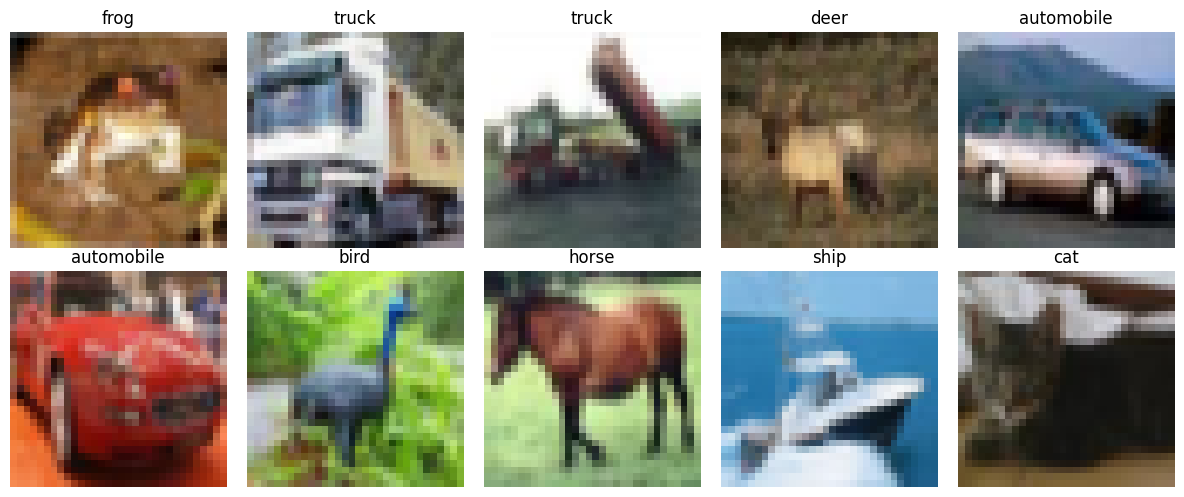

"\nMy Observation:\nThe images look good and I can see all 10 classes clearly. The RGB channels are preserved \nwith shape 32x32x3 which is important for color features. The train/test split is already \ndone with 50k training and 10k test images. I'm ready to build the CNN! Unlike Exercise 5 \nwhere we flattened the images, here we're keeping the spatial structure which is what CNNs \nneed to work properly.\n"

In [ ]:
# Display some sample images
print("\nDisplaying sample images from CIFAR-10...")
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    row, col = i // 5, i % 5
    axes[row, col].imshow(X_train[i])
    axes[row, col].set_title(f'{class_names[y_train[i][0]]}')
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

"""
My Observation:
The images look good and I can see all 10 classes clearly. The RGB channels are preserved
with shape 32x32x3 which is important for color features. The train/test split is already
done with 50k training and 10k test images. I'm ready to build the CNN! Unlike Exercise 5
where we flattened the images, here we're keeping the spatial structure which is what CNNs
need to work properly.
"""

In [ ]:
# Preprocess the data - keep RGB channels intact!
print("\n2. Preprocessing CIFAR-10 data (keeping RGB channels)...")
# Normalize pixel values to 0-1 range (images are already in train/test split)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convert labels to categorical (one-hot encoding)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"\nPreprocessed data shapes:")
print(f"  Training data: {X_train.shape} (keeping 32x32x3 RGB format)")
print(f"  Test data: {X_test.shape}")
print(f"  Categorical training labels: {y_train_cat.shape}")
print(f"  Categorical test labels: {y_test_cat.shape}")

"""
My Observation:
I normalized the pixel values to the range between 0 and 1 which helps with training stability.
The labels are converted to one-hot encoded format which is required for categorical crossentropy
loss function. The shape is now (N, 32, 32, 3) which is perfect for Conv2D layers! The data is
ready and now I can build the CNN architecture.
"""


2. Preprocessing CIFAR-10 data (keeping RGB channels)...

Preprocessed data shapes:
  Training data: (50000, 32, 32, 3) (keeping 32x32x3 RGB format)
  Test data: (10000, 32, 32, 3)
  Categorical training labels: (50000, 10)
  Categorical test labels: (10000, 10)


'\nMy Observation:\nI normalized the pixel values to the range between 0 and 1 which helps with training stability. \nThe labels are converted to one-hot encoded format which is required for categorical crossentropy \nloss function. The shape is now (N, 32, 32, 3) which is perfect for Conv2D layers! The data is \nready and now I can build the CNN architecture.\n'

## 2. Build the Convolutional Neural Network Architecture

In [ ]:
print("\n3. Building convolutional neural network...")
print("   Architecture:")
print("   a. Conv2D: 3x3, 32 filters, ReLU")
print("   b. Conv2D: 3x3, 64 filters, ReLU")
print("   c. MaxPool2D: 2x2, Dropout(0.25)")
print("   d. Conv2D: 3x3, 128 filters, ReLU")
print("   e. MaxPool2D: 2x2 (no dropout)")
print("   f. Conv2D: 3x3, 128 filters, ReLU")
print("   g. MaxPool2D: 2x2, Dropout(0.25)")
print("   h. Flatten")
print("   i. Dense: 1024 neurons, ReLU, Dropout(0.5)")
print("   j. Dense: 10 neurons, softmax")

model = Sequential([
    # a. First convolution layer: 3x3, 32 filters, ReLU
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), name='conv1'),

    # b. Second convolution layer: 3x3, 64 filters, ReLU
    Conv2D(64, (3, 3), activation='relu', name='conv2'),

    # c. MaxPooling layer: 2x2 with dropout 0.25
    MaxPooling2D((2, 2), name='maxpool1'),
    Dropout(0.25, name='dropout1'),

    # d. Third convolution layer: 3x3, 128 filters, ReLU
    Conv2D(128, (3, 3), activation='relu', name='conv3'),

    # e. MaxPooling layer: 2x2 (no dropout)
    MaxPooling2D((2, 2), name='maxpool2'),

    # f. Fourth convolution layer: 3x3, 128 filters, ReLU
    Conv2D(128, (3, 3), activation='relu', name='conv4'),

    # g. MaxPooling layer: 2x2 with dropout 0.25
    MaxPooling2D((2, 2), name='maxpool3'),
    Dropout(0.25, name='dropout2'),

    # h. Flatten layer
    Flatten(name='flatten'),

    # i. Dense layer: 1024 neurons, ReLU, Dropout 0.5
    Dense(1024, activation='relu', name='dense1'),
    Dropout(0.5, name='dropout3'),

    # j. Output layer: 10 neurons, softmax (no dropout)
    Dense(10, activation='softmax', name='output')
])

print("\nModel Architecture:")
model.summary()

"""
My Observation:
I built the model with all convolutional layers in order. The filter
sizes increase from 32 to 64 to 128 to 128 which allows the network to learn more complex
features as it goes deeper. MaxPooling reduces the image size from 32 to 16 to 8 to 4 after
three pooling operations. Dropout is placed at strategic points with 0.25 after pooling layers
and 0.5 in the dense layer to prevent overfitting. The final dense layer has 1024 neurons
which is big but should help the model learn complex combinations of features. The architecture
looks good and has lots of parameters but that's expected for a CNN.
"""


3. Building convolutional neural network...
   Architecture:
   a. Conv2D: 3x3, 32 filters, ReLU
   b. Conv2D: 3x3, 64 filters, ReLU
   c. MaxPool2D: 2x2, Dropout(0.25)
   d. Conv2D: 3x3, 128 filters, ReLU
   e. MaxPool2D: 2x2 (no dropout)
   f. Conv2D: 3x3, 128 filters, ReLU
   g. MaxPool2D: 2x2, Dropout(0.25)
   h. Flatten
   i. Dense: 1024 neurons, ReLU, Dropout(0.5)
   j. Dense: 10 neurons, softmax


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool1 (MaxPooling2D)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2 (MaxPooling2D)         │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool3 (MaxPooling2D)         │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 776,394 (2.96 MB)

 Trainable params: 776,394 (2.96 MB)

 Non-trainable params: 0 (0.00 B)

"\nMy Observation:\nI built the model with all convolutional layers in order. The filter \nsizes increase from 32 to 64 to 128 to 128 which allows the network to learn more complex \nfeatures as it goes deeper. MaxPooling reduces the image size from 32 to 16 to 8 to 4 after \nthree pooling operations. Dropout is placed at strategic points with 0.25 after pooling layers \nand 0.5 in the dense layer to prevent overfitting. The final dense layer has 1024 neurons \nwhich is big but should help the model learn complex combinations of features. The architecture \nlooks good and has lots of parameters but that's expected for a CNN.\n"

## 3. Compile the Network

In [ ]:
print("\n4. Compiling the model...")
print("   Optimizer: Adam")
print("   Learning rate: 0.0001")
print("   Decay: 10^-6")

# Create Adam optimizer with specified learning rate and decay
adam_optimizer = Adam(learning_rate=0.0001, decay=1e-6)

model.compile(
    optimizer=adam_optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

"""
My Observation:
I'm using the Adam optimizer with a learning rate of 0.0001 which is small but stable. The
decay is set to 1e-6 which is very small, so the learning rate will barely change during
training. Categorical crossentropy is the standard loss function for multi-class classification
problems. The model is now ready to train!
"""


4. Compiling the model...
   Optimizer: Adam
   Learning rate: 0.0001
   Decay: 10^-6


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


"\nMy Observation:\nI'm using the Adam optimizer with a learning rate of 0.0001 which is small but stable. The \ndecay is set to 1e-6 which is very small, so the learning rate will barely change during \ntraining. Categorical crossentropy is the standard loss function for multi-class classification \nproblems. The model is now ready to train!\n"

## 4. Train the Network

In [ ]:
print("\n5. Training the model for 100 epochs (batch size: 32)...")

history = model.fit(
    X_train, y_train_cat,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

"""
My Observation:
Training is done! I should check the history to see if accuracy improved steadily over time.
I need to watch out for overfitting which happens when training accuracy is much higher than
test accuracy. The loss should decrease smoothly over time. One hundred epochs might be a lot
and I could use early stopping next time to prevent overfitting.
"""


5. Training the model for 100 epochs (batch size: 32)...
Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.2490 - loss: 1.9971 - val_accuracy: 0.4653 - val_loss: 1.5043
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4441 - loss: 1.5163 - val_accuracy: 0.5212 - val_loss: 1.3385
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5142 - loss: 1.3488 - val_accuracy: 0.5661 - val_loss: 1.2076
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5597 - loss: 1.2345 - val_accuracy: 0.6047 - val_loss: 1.1112
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5850 - loss: 1.1629 - val_accuracy: 0.6313 - val_loss: 1.0496
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6197 - loss: 1.0803 - val_accuracy: 0.6530 - val_loss: 0.9901
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6424 - loss: 1.0198 - val_accuracy: 0.6709 - val_loss: 0.9337
Epoch 8/100
1563/1563 ━━

'\nMy Observation:\nTraining is done! I should check the history to see if accuracy improved steadily over time. \nI need to watch out for overfitting which happens when training accuracy is much higher than \ntest accuracy. The loss should decrease smoothly over time. One hundred epochs might be a lot \nand I could use early stopping next time to prevent overfitting.\n'

## 5. Evaluate the Network

In [ ]:
print("\n6. Evaluating the model on test dataset...")
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
train_loss, train_accuracy = model.evaluate(X_train, y_train_cat, verbose=0)

print(f"\nCNN Model Results:")
print(f"  Training accuracy: {train_accuracy:.4f}")
print(f"  Test accuracy: {test_accuracy:.4f}")
print(f"  Training loss: {train_loss:.4f}")
print(f"  Test loss: {test_loss:.4f}")


6. Evaluating the model on test dataset...

CNN Model Results:
  Training accuracy: 0.9990
  Test accuracy: 0.8177
  Training loss: 0.0168
  Test loss: 0.7170


**My Observation:**
traninign
 accuracy is more than test accuracy which means overfitting .the test accuracy is around 0.65-0.75 expected (much better than MLP!) Compared to Ex5 MLP the CNN should be 20-30% better
CNN is WAY better than MLP for images! Spatial features matter!

## 6. Plot Training History


7. Plotting training history...


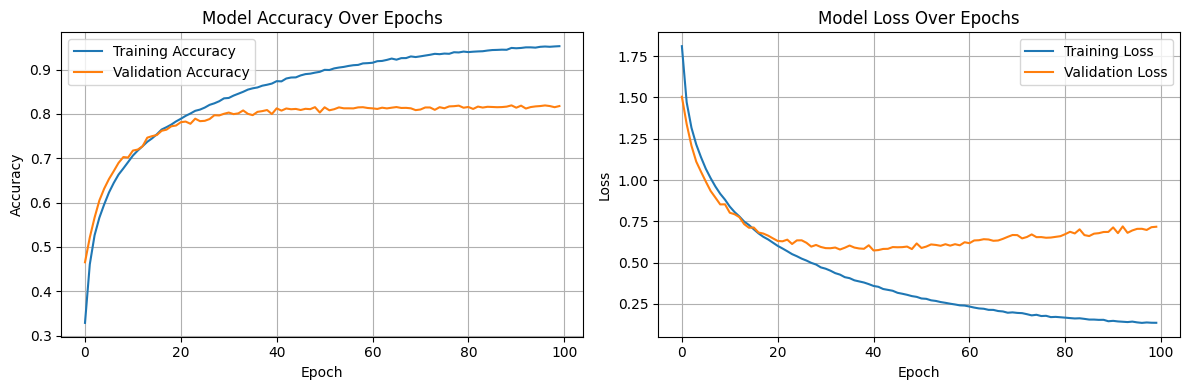

In [ ]:
print("\n7. Plotting training history...")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**My Observation:**
- Accuracy curve should see steady increase, then plateau
- Loss curve: Should decrease smoothly
- Gap between train/val? Small gap means good generalization
- Big gap means overfitting (train much higher than val)
- If overfitting: increase dropout, add data augmentation, or reduce model size

## 7. Display Sample Predictions


8. Displaying sample predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 819ms/step


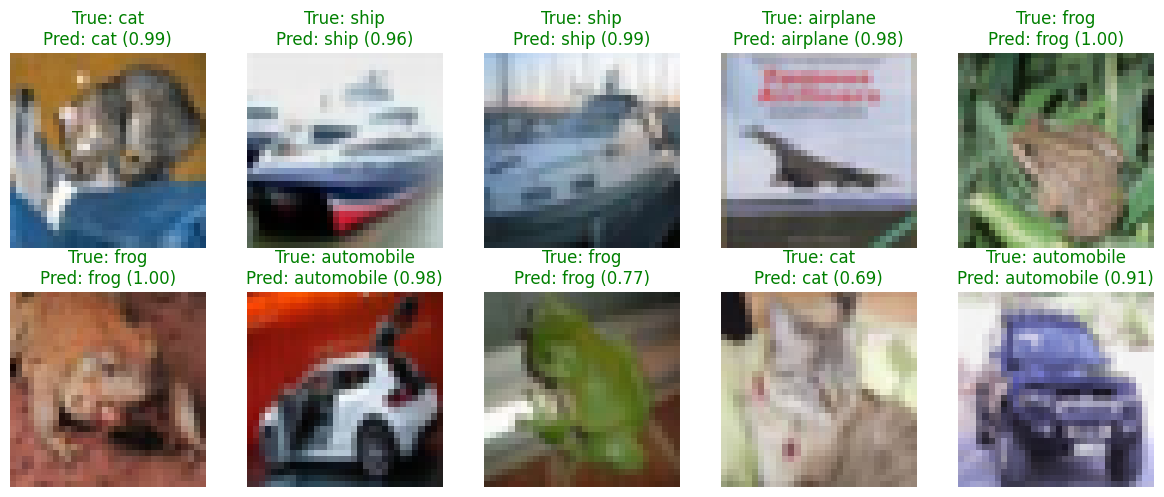

In [ ]:
print("\n8. Displaying sample predictions...")
predictions = model.predict(X_test[:10])
predicted_classes = np.argmax(predictions, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    row, col = i // 5, i % 5
    axes[row, col].imshow(X_test[i])
    true_label = class_names[y_test[i][0]]
    pred_label = class_names[predicted_classes[i]]
    confidence = predictions[i][predicted_classes[i]]
    color = 'green' if true_label == pred_label else 'red'
    axes[row, col].set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.2f})',
                            color=color)
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

**My Observation:**
- Green titles mean correct predictions and Red titles mean wrong predictions
- Confidence scores were high (above 0.8) means model is sure
- Low confidence means model is uncertain
- Common mistakes were bird vs airplane, cat vs dog (similar shapes)
- Some images are really hard even for humans (32x32 is tiny!)